In [141]:
# pip install torch torchaudio torchcodec 
# pip install transformers jiwer ipywidgets
import os 
import numpy as np 
import matplotlib.pyplot as plt 
from tqdm import tqdm # for displaying process bar
import torch 
import torch.nn as nn 
from torch import optim
from torch.utils.data import Dataset, DataLoader
import torchaudio
import torchaudio.transforms as T 
import torchaudio.functional as F 
from transformers import Wav2Vec2CTCTokenizer, get_cosine_schedule_with_warmup 
from jiwer import wer # to evaluate the model 
from pathlib import Path
import shutil
torch.set_num_threads(os.cpu_count())


### DeepSpeech2: Intro to ASR 
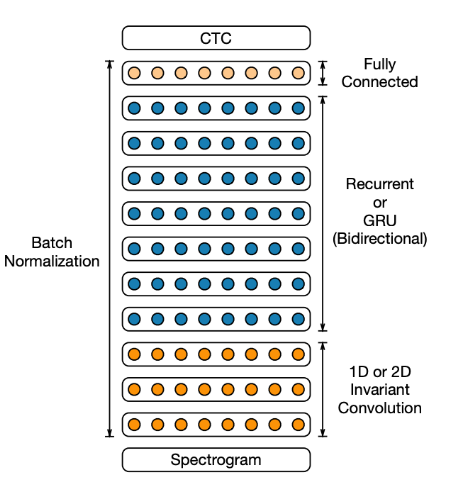

In [2]:
tokenizer = Wav2Vec2CTCTokenizer.from_pretrained("facebook/wav2vec2-base")
tokenizer # tokenizer nào cũng na ná nhau thôi, dùng cái này có sẵn đã có decoder trong đó rồi 

Wav2Vec2CTCTokenizer(name_or_path='facebook/wav2vec2-base', vocab_size=32, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'pad_token': '<pad>', 'word_delimiter_token': '|'}, added_tokens_decoder={
	0: AddedToken("<pad>", rstrip=True, lstrip=True, single_word=False, normalized=False, special=False),
	1: AddedToken("<s>", rstrip=True, lstrip=True, single_word=False, normalized=False, special=False),
	2: AddedToken("</s>", rstrip=True, lstrip=True, single_word=False, normalized=False, special=False),
	3: AddedToken("<unk>", rstrip=True, lstrip=True, single_word=False, normalized=False, special=False),
	4: AddedToken("|", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [3]:
tokenizer.vocab
# <pad>: blank token for repeating characters vd: hh.ee.ll.-.lo => colapse into hello

{'<pad>': 0,
 '<s>': 1,
 '</s>': 2,
 '<unk>': 3,
 '|': 4,
 'E': 5,
 'T': 6,
 'A': 7,
 'O': 8,
 'N': 9,
 'I': 10,
 'H': 11,
 'S': 12,
 'R': 13,
 'D': 14,
 'L': 15,
 'U': 16,
 'M': 17,
 'W': 18,
 'C': 19,
 'F': 20,
 'G': 21,
 'Y': 22,
 'P': 23,
 'B': 24,
 'V': 25,
 'K': 26,
 "'": 27,
 'X': 28,
 'J': 29,
 'Q': 30,
 'Z': 31}

In [4]:
DATASET_ROOT = "C:/Users/HuyenDT/Downloads/LibriSpeech"
os.listdir(DATASET_ROOT)

['BOOKS.TXT',
 'CHAPTERS.TXT',
 'dev-other',
 'LICENSE.TXT',
 'README.TXT',
 'SPEAKERS.TXT',
 'test-other']

In [5]:
np.max([int(i) for i in os.listdir("dataset_cache")]) + 1

np.int64(5)

In [6]:
len(os.listdir("dataset_cache"))

2

In [7]:
class LibrispeechDataset(Dataset):

    def __init__(self, 
                 path_to_data_root, 
                 include_splits = ["dev-other"], # ["train-clean-100", "train-clean-360", "train-other-500"], 
                 sampling_rate = 16000, 
                 num_audio_channels = 1,
                 is_from_cached=False,
                 cached_path = "dataset_cache",
                 cache_version = 0): 

        self.sampling_rate = sampling_rate 
        self.num_audio_channels = num_audio_channels

        # preload data 
        self.data = []

        if (is_from_cached and cache_version > 0 and os.path.exists(os.path.join(cached_path, str(cache_version)))): # Load from cache 
            print("Loading cached dataset...")
            folder_path = os.path.join(cached_path, str(cache_version))
            self.data = [torch.load(os.path.join(folder_path, f)) for f in os.listdir(folder_path)]
        else: 
            self.build_data_from_files(path_to_data_root, include_splits, cached_path, cache_version)

    def build_data_from_files(self, path_to_data_root, include_splits, cached_path, cache_version): 
            # Load from folders 
            if isinstance(include_splits, str): # if it is a string 
                include_splits = [include_splits] # to make sure include_splits is a list, even if it is a string => 1 item
            
            self.librispeech_data = []
            for s in include_splits: 
                path_to_split = os.path.join(path_to_data_root, s)  # format: speaker/section/audio
                
                for speaker in os.listdir(path_to_split): 
                    path_to_speaker = os.path.join(path_to_split, speaker)
                    # print(speaker)

                    for section in os.listdir(path_to_speaker): 
                        path_to_section = os.path.join(path_to_speaker, section)
                        files = os.listdir(path_to_section)

                        transcript_file = [path for path in files if ".txt" in path][0]
                        with open(os.path.join(path_to_section, transcript_file), "r") as f: 
                            transcripts = f.readlines()

                        for line in transcripts: 
                            split_line = line.split() # default is space => return an array
                            audio_root = split_line[0]
                            audio_file = audio_root + ".flac"
                            full_path_to_audio_file = os.path.join(path_to_section, audio_file)
                            transcript = " ".join(split_line[1:]).strip()

                            self.librispeech_data.append(
                                (full_path_to_audio_file, transcript, audio_root)
                            )
            # print(len(self.librispeech_data))
            # Create a transform to transfrom the audio waveform → Mel Spectrogram: display Frequency by time (Time × Frequency)
            # Waveform (1D signal) => STFT (Fourier Transform) -> Mel scaling -> Mel Spectrogram (2D tensor)
            # Mel scale: based on how people can hear the voice to separate into level (is log(Hz))
            # n_fft?, window_size? window_fn: torch.hann_window
            self.audio2mels = T.MelSpectrogram( # default n_fft & hanning_window
                sample_rate = self.sampling_rate, # tấn suất lấy mẫu của audio: esim: 16000 Hz = 1 giây có 16000 mẫu
                n_mels=80 # Mel filter banks: (optimal value) Output sẽ có 80 hàng (80 tần số mel), => chia trục tần số thành 80 dải Mel.
                        # 40: lost data, 128-256: heavy, more RAM, and training time,
            )

            self.amp2db = T.AmplitudeToDB(
                top_db=80.0
            )

            # check cached version 
            max_version = self.get_max_cached_version(cached_path, cache_version)
            path_to_cache_version = os.path.join(cached_path, str(max_version))
            if os.path.exists(path_to_cache_version):
                shutil.rmtree(path_to_cache_version)
            os.makedirs(path_to_cache_version, exist_ok=True)

            #print(max_version)
            for path, tran, audio_name in self.librispeech_data: 
                #print(i, path, tran)
                audio, orig_sr = torchaudio.load(path, normalize=True)
                if orig_sr != self.sampling_rate:
                    audio = torchaudio.functional.resample(audio, orig_freq=orig_sr, new_freq=self.sampling_rate) # re-sample to 16.000

                mel = self.audio2mels(audio) # to MelSpectrogram
                mel = self.amp2db(mel) 
                mel = (mel - mel.mean())/(mel.std() + 1e-6) # 1e-6 to avoid deviding by zero, to nomalize

                tokenized_transcript = torch.tensor(tokenizer.encode(tran))
                item = {
                        "input_values": mel[0].T, # to feed time dimension first, then feature dimension after
                        "labels": tokenized_transcript
                    }
                self.data.append(item)

                # save to cache
                path_to_save = os.path.join(path_to_cache_version, audio_name + ".pt")
                torch.save(item,path_to_save)

    def get_max_cached_version(self, cached_path, cache_version): 
        if(cache_version > 0): 
            return cache_version
        else: 
            return np.max([int(i) for i in os.listdir(cached_path)]) 
    
    def __len__(self): 
        '''
            - DataLoader khow how many samples dataset has
            - To calculate the number of batch
            - Shuffle correctly
        '''
        return len(self.librispeech_data)
    
    def __getitem__(self, index):
        # path_to_audio, transcript = self.librispeech_data[index]
        # audio, orig_sr = torchaudio.load(path_to_audio, normalize=True) #normalize: true, convert into [-1, 1], normalize: false, audio bit is between [0, 255]
        # if orig_sr != self.sampling_rate:
        #     audio = torchaudio.functional.resample(audio, orig_freq=orig_sr, new_freq=self.sampling_rate) # re-sample to 16.000

        # # audio: waveform
        # mel = self.audio2mels(audio) # to MelSpectrogram
        # # print(audio.shape) => [1, 170400]
        # # print(mel.shape) => [1, 80, 853]: 80 bins, 
        # # 853 time steps: after sliding window of hann_window (400 windowsize with 200 overlap default value)

        # mel = self.amp2db(mel) # to amplitude to Decibel => see diff frequencies lighting up at the diff time steps
        
        # # plt.figure(figsize=(15,5))
        # # plt.imshow(mel[0])
        # # plt.show()

        # mel = (mel - mel.mean())/(mel.std() + 1e-6) # 1e-6 to avoid deviding by zero, to nomalize

        # tokenized_transcript = torch.tensor(tokenizer.encode(transcript))
        # # print(transcript)
        # # print(tokenized_transcript)

        # sample = {
        #     "input_values": mel[0].T, # to feed time dimension first, then feature dimension after
        #     "labels": tokenized_transcript
        #     # "audio": audio,
        #     #"transcript": transcript
        # }
        #  return sample

        return self.data[index]
       

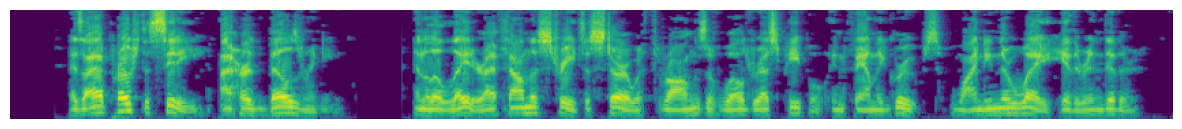

In [8]:
# Load a sample and visualize
dataset = LibrispeechDataset("C:/Users/HuyenDT/Downloads/LibriSpeech", include_splits = ["dev-other"], is_from_cached = False, cache_version=1)
sample =next(iter(dataset))

#sample = torch.load("dataset_cache/4/6841-88291-0000.pt")

# visualize (and flip so low frequencies are at the bottom)
plt.figure(figsize=(15, 5))
plt.imshow(sample["input_values"].T)
plt.axis("off")
plt.gca().invert_yaxis() # gca: Get Current Axes
plt.show()

An audio example 

In [9]:
from IPython.display import Audio 

folder_path = os.path.join(DATASET_ROOT, "dev-other")
speaker = "6841"
section = "88291"
audio_index = 0
folder_root = os.path.join(folder_path, speaker, section)
script_path = os.path.join(folder_root, f"{speaker}-{section}.trans.txt")

#print(script_path)
with open(script_path, 'r') as f:
   transcripts = f.readlines()

transcript_line = transcripts[audio_index]
parts = transcript_line.split()

audio_name = parts[0]
audio_path = os.path.join(folder_root, f"{audio_name}.flac")
audio_transrcipt = " ".join(parts[1:]).strip()

print(audio_transrcipt)

audio, sampling_rate = torchaudio.load(audio_path)
Audio(audio, rate=sampling_rate)

BUT SINCE THERE EXISTED FOR US NO RESPONSIBILITY WE EACH REPORTED DUTIFULLY AT THE ROLL CALL OF HABIT AND DROPPED BACK INTO OUR BLANKETS WITH A GRATEFUL SIGH


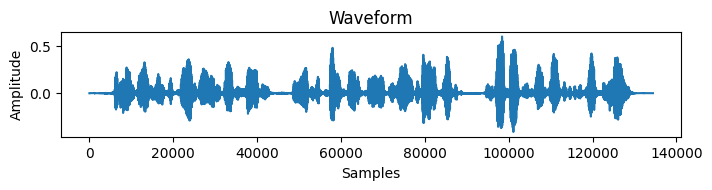

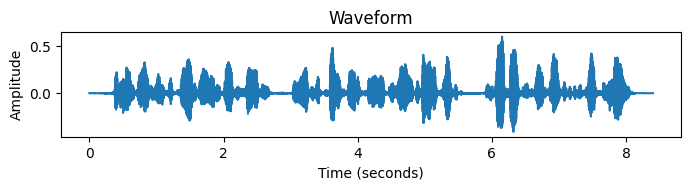

In [10]:
audio = audio.squeeze()

plt.figure(figsize=(8, 3))
plt.subplot(2, 1, 1)
plt.plot(audio)
plt.title("Waveform")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

num_samples = len(audio)
time_axis = torch.arange(num_samples) / 16000

plt.figure(figsize=(8, 3))
plt.subplot(2, 1, 2)
plt.plot(time_axis, audio)
plt.title("Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

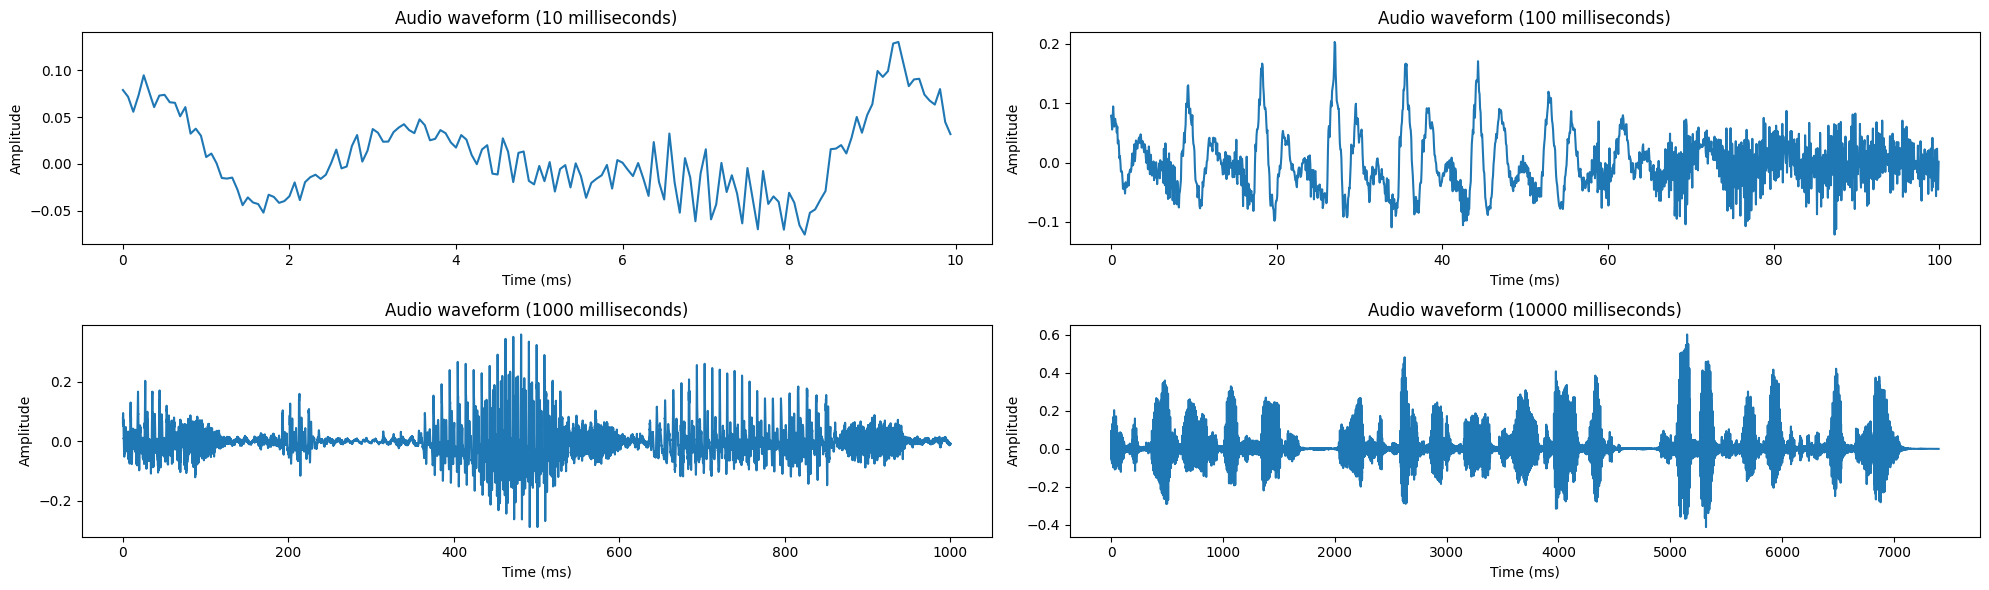

In [11]:
import matplotlib.pyplot as plt 
import numpy as np 

def drawWaveform (start_time_ms, audioLen, axes, sample_rate = 16000): 
    start_time_ms = start_time_ms 
    end_time_ms = start_time_ms + audioLen # milliseconds: 10, 100, 1000: this is how amplitude values look like for the next 10, 100... miliseconds

    start_idx = int(start_time_ms * sample_rate / 1000) # sample_rate/sec => need to divide by 1000
    end_idx = int(end_time_ms * sample_rate / 1000)

    audio_np = audio[start_idx: end_idx]

    # Create time axis in milliseconds
    time_ms = np.arange(len(audio_np)) * (1000/sample_rate)

    axes.plot(time_ms, audio_np)
    axes.set_xlabel('Time (ms)')
    axes.set_ylabel('Amplitude')
    axes.set_title(f"Audio waveform ({audioLen} milliseconds)")
    # plt.show()

fig, axes = plt.subplots(2, 2, figsize=(20, 6))
axes = axes.flatten() 

drawWaveform(1000, 10, axes[0])
drawWaveform(1000, 100, axes[1])
drawWaveform(1000, 1000, axes[2])
drawWaveform(1000, 10000, axes[3])
plt.tight_layout()

### Collate Function 
- spectrograms: Pad spectrograms to longest in the batch and concatenate 
- seq_lens: just so we know the original size of each sample before we padded 
- packed_transcript: Packed Padding of Labels (CTC Loss can take a single vector of all target tokens across all samples in the batch)
- target_lengths: Because we concatenated all our labels into a single vector, CTC needs to know how mnay token go with each sample in the batch 

=> RNN in PyTorch can take Packed Padded data => only need to sort the seq lengths in the batch are longest to shortest 

Input Values: torch.Size([5, 1, 80, 853])
Seq Lens: tensor([853, 771, 691, 298, 293])
Labels: torch.Size([550])
Target Lengths: tensor([181, 141, 114,  61,  53])
OK, same length


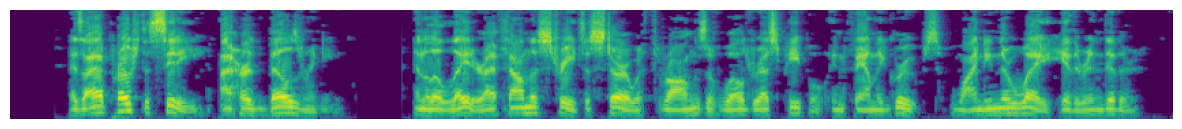

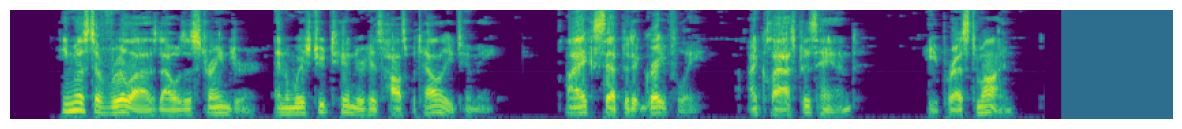

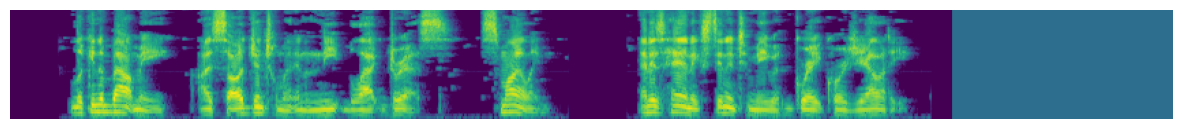

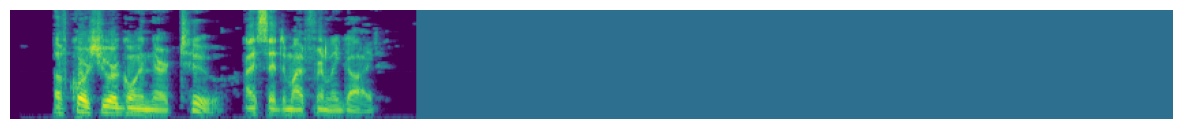

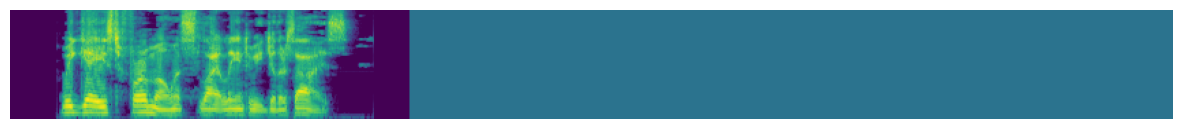

In [12]:
def collate_fun(batch): # combine multiple samples into batchs
    #print(batch[0]["input_values"].shape)  # time steps of each audio is 853
    #print(batch[1]["input_values"].shape)  # each has diff length 

    batch = sorted(batch, key = lambda x: x["input_values"].shape[0], reverse=True)
    # print(batch[0]["input_values"].shape)  # after sort 
    # print(batch[1]["input_values"].shape) 
    

    batch_mels = [sample["input_values"] for sample in batch]
    batch_transcripts = [sample["labels"] for sample in batch]

    seq_lens = torch.tensor([b.shape[0] for b in batch_mels], dtype=torch.long)

    spectrograms = torch.nn.utils.rnn.pad_sequence(batch_mels, batch_first=True, padding_value=0)
    # print(spectrograms.shape) # [5, 853, 80]: batch_size, seq length, hidden size 
    
    spectrograms = spectrograms.unsqueeze(1) # add 1 more dimension after the first dimension, unsqueeze(0): at the beginning, unsqueeze(-1): at the end 
    # print(spectrograms.shape) # [5, 1, 853, 80]

    spectrograms = spectrograms.transpose(-1, -2) # switch the position of 2 last dimensions

    target_lengths = torch.tensor([len(t) for t in batch_transcripts], dtype=torch.long)
    packed_transcripts = torch.cat(batch_transcripts)

    # print(target_lengths)
    # print(packed_transcripts)
    batch = {
        "input_values": spectrograms,
        "seq_lens": seq_lens, 
        "labels": packed_transcripts, 
        "target_lengths": target_lengths
    }

    return batch

# test collate func 
loader = DataLoader(dataset=dataset, batch_size=5, collate_fn=collate_fun)
batch = next(iter(loader))

print("Input Values:", batch["input_values"].shape)
print("Seq Lens:", batch["seq_lens"]) # the 
print("Labels:", batch["labels"].shape) # concat all labels together
print("Target Lengths:", batch["target_lengths"]) # how many labels are for first, second... samples

# as required by CTC loss, sum of the target lengths must equal the length127th of the flattened lables 
if batch["target_lengths"].sum() == len(batch["labels"]): 
    print("OK, same length")

for s in batch["input_values"]: 
    plt.figure(figsize=(15, 5))
    plt.imshow(s.squeeze()) # remove batch dim when decode a sample
    plt.axis("off")
    plt.gca().invert_yaxis() # gca: Get Current Axes
    plt.show()


In [13]:
batch["input_values"].shape 

torch.Size([5, 1, 80, 853])

### Masked Convolution

When doing convolutions on our samples, need to
- convolve on the spectrograms
- do padding 


### Adjust for Convolution Downsample
Convolution is 2d (its an image) so we will have a convolution in both the time dimension but also the feature (mel bins) dimension. We are not caring too much about the mel bins dimension right now (it's always 80 now), but the time dimension that can change. 

This means when we write things like our kernel size of (3,3), it is a kernel sie of 3 in the mel dimension and a kernal size of 3 in the time dimension. 

Similarity, if we write our convolution as (1, 2), we will have stride of 1 along the mel dimension, and then a stride of 2 along the time dimension 

In [14]:

# in_channels: 1 from the second dimension: batch["input_values"].shape [5, 1, 80, 853]
# out_channels = số filter bạn muốn học => how many features 
# kernel_size
# stride: Dùng để giảm chiều thời gian / freq, giống pooling
# stride(stride_height, stride_width) => stride(1,2): keep the freq the same, reduce half of time, down sampling by a factor of two
# => reduce time steps for RNN, save computation 

# padding=(pad_height, pad_width) : 1 => padding at the top & bottom, not horizontal => keep 80, 1: keep same, 0: padding 0 at this dimension
conv = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=(3,3), stride=(1,2), padding=(1,0))

print(batch["input_values"].shape)
output = conv(batch["input_values"])
print(output.shape)

torch.Size([5, 1, 80, 853])
torch.Size([5, 1, 80, 426])


So we have downsampled out total batch length by a half, some of those timestamps were padding => now what parts of the downsampled signal came from padding, and what parts came from non-padding?  

You can see this in the [Conv2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html) docs from PyTorch! 

In [15]:
padding = 0 
kernel_size = 3 
stride = 2

print("Input Seq Lens:", batch["seq_lens"])
output_seq_lens = torch.floor((batch["seq_lens"] + (2 * padding) - (kernel_size -1) -1)//stride + 1)
print("Ouput Seq Lens:", output_seq_lens)
# the max length is: 426 (the first, lengthest item)
# the second item: only first 385 outputs are valid, from 385-> 426 is padded
# the third item...

Input Seq Lens: tensor([853, 771, 691, 298, 293])
Ouput Seq Lens: tensor([426, 385, 345, 148, 146])


### Masking the Output
We now know the output sequence length of every spectrogram, meaning any sequence length after those are not valid. 

We must remask them to 0 to help model not to calculate loss of them 

=> We create a new [0, 1] mask based on the output sequence lengths and multiply our data by it, zeroing out any non-valid convolutiona output coming from the padding regions 

In [16]:
output_seq_lens

tensor([426, 385, 345, 148, 146])

In [17]:
mask = torch.nn.utils.rnn.pad_sequence([torch.ones(i) for i in output_seq_lens], padding_value=0, batch_first=True)
mask 
# 426 items with value of 1
# 385 items with value of 1...

tensor([[1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 0., 0., 0.],
        [1., 1., 1.,  ..., 0., 0., 0.],
        [1., 1., 1.,  ..., 0., 0., 0.],
        [1., 1., 1.,  ..., 0., 0., 0.]])

In [18]:
print(mask.shape)
print(output.shape)

torch.Size([5, 426])
torch.Size([5, 1, 80, 426])


In [19]:
mask = mask.unsqueeze(1).unsqueeze(1) # unsqueeze = np.newaxis in numpy
print(mask.shape)
print(output.shape)

torch.Size([5, 1, 1, 426])
torch.Size([5, 1, 80, 426])


In [20]:
output = output * mask
print(output)

tensor([[[[0.5241, 0.5241, 0.5241,  ..., 0.0657, 0.0091, 0.3968],
          [1.0986, 1.0986, 1.0986,  ..., 0.5549, 0.6641, 0.7926],
          [1.0986, 1.0986, 1.0986,  ..., 0.5933, 0.8330, 0.7197],
          ...,
          [1.0986, 1.0986, 1.0986,  ..., 1.0986, 0.8194, 0.7446],
          [1.0986, 1.0986, 1.0986,  ..., 1.0986, 0.7695, 0.6676],
          [0.6606, 0.6606, 0.6606,  ..., 0.6606, 0.4482, 0.3673]]],


        [[[0.4611, 0.4611, 0.4611,  ..., -0.0000, -0.0000, -0.0000],
          [0.9861, 0.9861, 0.9861,  ..., -0.0000, -0.0000, -0.0000],
          [0.9861, 0.9861, 0.9861,  ..., -0.0000, -0.0000, -0.0000],
          ...,
          [0.9861, 0.9861, 0.9861,  ..., -0.0000, -0.0000, -0.0000],
          [0.9861, 0.9861, 0.9861,  ..., -0.0000, -0.0000, -0.0000],
          [0.5859, 0.5859, 0.5859,  ..., -0.0000, -0.0000, -0.0000]]],


        [[[0.4216, 0.4216, 0.4216,  ..., -0.0000, -0.0000, -0.0000],
          [0.9154, 0.9154, 0.9154,  ..., -0.0000, -0.0000, -0.0000],
          [0.9

### Create the Masked Conv2d 
create a wrapper on the existing convolution 

In [21]:
class MaskedConvd2d(nn.Conv2d): # inherit from nn.Conv2d
    def __init__(self, 
            in_channels, 
            out_channels, 
            kernel_size, 
            stride, 
            padding=0, 
            bias=True, 
            **kwargs): 
        super(MaskedConvd2d, self).__init__(in_channels=in_channels, 
                                            out_channels=out_channels,
                                            kernel_size=kernel_size,
                                            stride=stride,
                                            padding=padding,
                                            bias=bias,
                                            **kwargs)
    
    def forward(self, x, seq_lens): # define how data go through the model - the computing process of nn, seq_lens: valid lengths that come out of it 
        batch_size , channels, height, width = x.shape # standard form for a convolution (like for an image)
        output_seq_lens = self._compute_out_seq_len(seq_lens)

        conv_out = super().forward(x) # using the original forward method of the original convolution on this data

        mask = torch.zeros(batch_size, output_seq_lens.max(), device=x.device) # device list: CPU/GPU => x, mask need to be on the same device to avoid errors

        for i, length in enumerate(output_seq_lens): 
            mask[i, :length] = 1

        mask = mask.unsqueeze(1).unsqueeze(1)

        conv_out = conv_out * mask

        return conv_out, output_seq_lens

    def _compute_out_seq_len(self, seq_lens): 
        return torch.floor((seq_lens + (2 * self.padding[1]) - (self.kernel_size[1] -1) -1) // self.stride[1]) + 1

### Convolutional Feature Extractor 

Create a stack of two convolutions with BatchNorm2d and the HardTanh Activation function 

The output of the convolutions will give the shape (Batch x Channels X Mel_features x time). To give this to the future RNN, we need to reshape it to (Batch x time x Channels * Mel_features)

from (B, C, H, W) => (B, C, H*W) ~ (B, embedding, tokens)
=> need to this format: (B, tokens, embedding)


In [22]:
class ConvolutionFeatureExtractor(nn.Module): 
    def __init__(self, in_channels = 1, out_channels = 32): # default from Nvidia implementation
        super(ConvolutionFeatureExtractor, self).__init__()

        self.conv1 = MaskedConvd2d(in_channels, out_channels, kernel_size=(11, 41), stride=(2,2), padding=(5, 20), bias=False) # co BatchNorm roi => no need bias
        self.bn1 = nn.BatchNorm2d(out_channels) # normalize the batch 

        self.conv2 = MaskedConvd2d(out_channels, out_channels, kernel_size=(11, 21), stride=(2,1), padding=(5, 10), bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels) # normalize the batch 

        self.output_feature_dim = 20 
        self.conv_output_features = self.output_feature_dim * out_channels

    def forward(self, x, seq_lens): 
        
        #print("Before conv1: ", x.shape)
        #print(seq_lens)

        x, seq_lens = self.conv1(x, seq_lens)
        x = self.bn1(x)
        x = torch.nn.functional.hardtanh(x)

       # print("\nAfter Convolution 1 layer: ", x.shape)
        #print(seq_lens)

        x, seq_lens = self.conv2(x, seq_lens)
        x = self.bn2(x)
        x = torch.nn.functional.hardtanh(x)

        #x = x.permute(0, 3, 1, 2) # change dimension orders from (0, 1, 2, 3) => (0, 3, 1, 2)
        #print("\nAfter Convolution 2 layer: ", x.shape)
        #print(seq_lens)

        x = x.permute(0, 3, 1, 2) # change dimension orders from (0, 1, 2, 3) => (0, 3, 1, 2)
        #print("\nAfter permute: ", x.shape)
        x = x.flatten(2) # flatten from the dimension with index = 2
        #print("\nAfter flatten: ", x.shape) 

        return x, seq_lens

c = ConvolutionFeatureExtractor()
c(batch["input_values"], batch["seq_lens"])

(tensor([[[-0.2911, -0.3468, -0.4261,  ..., -0.3881, -0.4182, -1.0000],
          [-0.2737, -0.3453, -0.5741,  ..., -0.6305, -0.6232, -1.0000],
          [-0.0297,  0.0189,  0.2463,  ..., -1.0000, -1.0000, -1.0000],
          ...,
          [ 1.0000,  1.0000,  1.0000,  ...,  0.3686, -0.5614, -0.0363],
          [ 1.0000,  1.0000,  1.0000,  ...,  0.6816, -0.3851,  0.0137],
          [ 1.0000,  1.0000,  1.0000,  ...,  1.0000, -0.1790,  0.3827]],
 
         [[-0.1443, -0.1345, -0.3179,  ..., -0.3284, -0.3378, -0.8631],
          [ 0.3044,  0.1272, -0.0551,  ..., -0.2924, -0.2212, -0.9983],
          [ 0.1760,  0.1301,  0.5555,  ..., -1.0000, -1.0000, -1.0000],
          ...,
          [ 0.0667,  0.0667,  0.0667,  ...,  0.0108,  0.0108,  0.0108],
          [ 0.0667,  0.0667,  0.0667,  ...,  0.0108,  0.0108,  0.0108],
          [ 0.0667,  0.0667,  0.0667,  ...,  0.0108,  0.0108,  0.0108]],
 
         [[-0.2381, -0.3541, -0.5106,  ..., -0.2675, -0.3277, -1.0000],
          [-0.1143, -0.3293,

After applying convolution 1:
- the same number of batch 
- from 1 channel => 32 channels
- 80 mel bins => 40 mel bins
- downsampled from 853 to 427 

After applying convolution 2:
- the same number of batch 
- from 1 channel => 32 channels
- 40 mel bins => 20 mel bins


### RNN Layer 

This is a Bidirectional RNN (can look both ways)

In [23]:
conv = ConvolutionFeatureExtractor()
conv_out, out_seq_lens = conv(batch["input_values"], batch["seq_lens"])
print(conv_out.shape) # [batch_size, time_steps, embeddings]
print(out_seq_lens)

torch.Size([5, 427, 640])
tensor([427, 386, 346, 149, 147])


**Packed Padding**

Removes the padding tokens
- pack_padded_sequence: convert padded_sequence tensor into PackedSequence to RNN 
- pad_packed_sequence: convert PackedSequence back to tensor padded

In [24]:
packed_conv_out = nn.utils.rnn.pack_padded_sequence(conv_out, out_seq_lens, batch_first=True) # batch_first: the first dimension is batch_size
print(packed_conv_out)
# packed_conv_out.data: all concatenated together, no padding 
# packed_conv_out.batch_sizes: batch_sizes[i] is the number of sequences that still have valid data at timestep i
# timestemp[0]: 5 sequences are valid .... timetemp[147]: 5
# timestemp[148]: only 4 are valid....
# => which indixes are valid at the diff samples 

PackedSequence(data=tensor([[ 0.7113,  1.0000,  1.0000,  ...,  0.2505,  0.9836, -0.1309],
        [ 0.2421,  1.0000,  1.0000,  ..., -0.0020,  1.0000,  0.1123],
        [ 0.4926,  1.0000,  1.0000,  ...,  0.2033,  0.9522, -0.1097],
        ...,
        [-0.9178, -0.8280,  0.1249,  ...,  0.4053,  0.6745,  0.0401],
        [-1.0000, -0.8850, -0.4442,  ..., -0.1870,  0.1277,  0.1922],
        [-0.1810,  0.0745,  0.1805,  ...,  0.2848,  0.1727,  0.5722]],
       grad_fn=<PackPaddedSequenceBackward0>), batch_sizes=tensor([5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
        5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
        5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
        5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
        5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
        5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       

In [25]:
print(out_seq_lens)
torch.unique(packed_conv_out.batch_sizes, return_counts=True) # len = 427 
# => after 147 times of 5 
# => 2 = (149-147) times of 4, 
# => 197 = (346 - 149) times of 3 ....

tensor([427, 386, 346, 149, 147])


(tensor([1, 2, 3, 4, 5]), tensor([ 41,  40, 197,   2, 147]))

In [26]:
class RNNLayer(nn.Module): 
    def __init__(self, input_size, 
                 hidden_size = 512): # what the invading implementaion used 
        super().__init__()

        self.hidden_size = hidden_size
        self.input_size = input_size

        self.rnn = nn.LSTM( # Long Short-Term Memory
            input_size = input_size, # no of features at each timestep 
            hidden_size=hidden_size, # no of neuron at hidden state 
            batch_first=True, 
            bidirectional=True, # when training the rnn, future steps can look in the past steps and vice versa as the entire input is passed at once
        )

        self.layernorm = nn.LayerNorm(2 * hidden_size) # need *2 as for both forward and backward direction with bidirectional=True

    def forward(self, x, seq_lens):
        batch, seq_len, embed_dim = x.shape 

        # packing to be used in rnn to save time processing 
        packed_x = nn.utils.rnn.pack_padded_sequence(x, seq_lens, batch_first=True)

        out, _ = self.rnn(packed_x)

        # unpacking 
        x, _ = nn.utils.rnn.pad_packed_sequence(out, total_length=seq_len, batch_first=True )

        x = self.layernorm(x) # normalize data

        return x 


### Put it together 

Put it all together to create our DeepSpeech2 model 

In [ ]:
class DeepSpeech2(nn.Module): 
    def __init__(self, 
                conv_in_channels = 1, 
                conv_out_channels = 32, 
                rnn_hidden_size = 128, # 512, # reduce model size
                rnn_depth = 2 # 5 # reduce model size
                ):
        
        super().__init__()

        self.feature_extractor = ConvolutionFeatureExtractor(conv_in_channels, conv_out_channels)

        self.output_hidden_features = self.feature_extractor.conv_output_features # 640 features 

        self.rnns = nn.ModuleList(  # a bunch of RNN 
            [
                # first layer: input_size = 640 
                # after that: input_size = 512 * 2 = 1024
                RNNLayer(input_size=self.output_hidden_features if i == 0 else 2 * rnn_hidden_size, hidden_size=rnn_hidden_size)
                for i in range(rnn_depth)
            ]
        )

        self.head = nn.Sequential( # output: probabilities for each vocab
            nn.Linear(2 * rnn_hidden_size, rnn_hidden_size), # input, output
            nn.Hardtanh(),
            nn.Linear(rnn_hidden_size, tokenizer.vocab_size) # fully connected layer to predict what the letter is said at this timestep?
        )


    def forward(self, x, seq_lens): 
        x, final_seq_lens = self.feature_extractor(x, seq_lens)

        for rnn in self.rnns: 
            x = rnn(x, final_seq_lens) # after convolution layer => final_seq_lens will never change

        x = self.head(x)
        
        return x, final_seq_lens
    
model = DeepSpeech2()
model

DeepSpeech2(
  (feature_extractor): ConvolutionFeatureExtractor(
    (conv1): MaskedConvd2d(1, 32, kernel_size=(11, 41), stride=(2, 2), padding=(5, 20), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): MaskedConvd2d(32, 32, kernel_size=(11, 21), stride=(2, 1), padding=(5, 10), bias=False)
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (rnns): ModuleList(
    (0): RNNLayer(
      (rnn): LSTM(640, 512, batch_first=True, bidirectional=True)
      (layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    )
    (1-4): 4 x RNNLayer(
      (rnn): LSTM(1024, 512, batch_first=True, bidirectional=True)
      (layernorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    )
  )
  (head): Sequential(
    (0): Linear(in_features=1024, out_features=512, bias=True)
    (1): Hardtanh(min_val=-1.0, max_val=1.0)
    (2): Linear(in_features=512, out_features=32, bias=

In [ ]:
### Training agurments 
BATCH_SIZE = 32
TRAINING_ITERATIONS = 50 # 50000 # how many iterations 
EVAL_ITERATIONS = 10  # 2500 # How often want to evaluate a learning reate 
LEARNING_RATE = 1e-4 # 10^(-4)
NUM_WORKERS = 0 # no of CPU (if has data preload => set NUM_WORKERS = 0)
DEVICE = "cuba" if torch.cuda.is_available() else "cpu"


In [ ]:
DATASET_ROOT = "C:/Users/HuyenDT/Downloads/LibriSpeech"

### Data loaders ###
trainset = LibrispeechDataset(path_to_data_root=DATASET_ROOT, include_splits=["dev-other"])
testset = LibrispeechDataset(path_to_data_root=DATASET_ROOT, include_splits=["test-other"])

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fun, num_workers=NUM_WORKERS)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fun, num_workers=NUM_WORKERS) # , persistent_workers=True when set multiple workers

### Define the model ###
model = DeepSpeech2(conv_in_channels=1, 
                    conv_out_channels=32,
                    rnn_hidden_size= 128  #512
                    ).to(DEVICE)

# numel: number of elements
params = sum([p.numel() for p in model.parameters()])
print("Total training Parameter: ", params)

### Optimizer ###
optimizer = optim.AdamW(params=model.parameters(), lr=LEARNING_RATE)
scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=500, num_training_steps=TRAINING_ITERATIONS)

Total training Parameter:  30727936


In [90]:
for batch in trainloader:
    print(batch["input_values"].shape)
    break

torch.Size([32, 1, 80, 849])


In [ ]:
best_val_loss = np.inf 
train = True 
completed_steps = 0 
train_his_loss, validation_his_loss = [], []
pbar = tqdm(range(TRAINING_ITERATIONS))

while train: 
    training_loss = []
    validation_loss = []

    for batch in trainloader: 
        # print(batch)
        logits, input_lengths = model(batch["input_values"].to(DEVICE), batch["seq_lens"])
        
        #print(logits.shape)
        #print(input_lengths)

        log_probs = nn.functional.log_softmax(logits, dim=-1) # dim=-1: apply softmax for the last dimension [batch_size, num_classes],
        #print(log_probs.shape) # => [batch_size, seq_lens, num_classes]
        log_probs = log_probs.transpose(0,1) # but CTC expect: [Time, batch_size, num_classes] => need to transpose two first dimensions

        # print(len(batch["labels"]), sum(batch["target_lengths"])) # the same number 

        loss = nn.functional.ctc_loss(
            log_probs=log_probs,
            targets=batch["labels"].to(DEVICE),
            input_lengths=input_lengths, 
            target_lengths=batch['target_lengths'].to(DEVICE),
            blank=tokenizer.pad_token_id, 
            reduction="mean"
        )

        # print(loss)

        loss.backward()
        optimizer.step() 
        optimizer.zero_grad(set_to_none=True)
        scheduler.step() 

        training_loss.append(loss.item())
        completed_steps += 1 
        pbar.update(1)

        if completed_steps % EVAL_ITERATIONS == 0: 
            print("Evaluating")
            model.eval() 

            for batch in tqdm(testloader): 
                ### Pass through model and get input_lengths (pocst convolutions) and logits ###
                with torch.no_grad(): # tells PyTorch to not calculate the gradients in this block 
                    logits, input_lengths = model(x=batch["input_values"].to(DEVICE), seq_lens=batch["seq_lens"])

                    #CTC expects log probabilities 
                    log_probs = nn.functional.log_softmax(logits, dim=-1)

                    # CTC also expects (TxBxC), we have (BxTxC)
                    log_probs = log_probs.transpose(0,1)

                    # Compute CTC loss 
                    loss = nn.functional.ctc_loss(
                        log_probs=log_probs,
                        targets=batch["labels"].to(DEVICE),
                        input_lengths=input_lengths, 
                        target_lengths=batch['target_lengths'].to(DEVICE),
                        blank=tokenizer.pad_token_id, 
                        reduction="mean"
                    )

                    # Store Loss
                    validation_loss.append(loss.item())
            
            training_loss_mean = np.mean(training_loss)
            valid_loss_mean = np.mean(validation_loss)

            # log to hist
            train_his_loss.append(training_loss_mean)
            validation_his_loss.append(valid_loss_mean)

            # Save model if val loss decreases 
            if valid_loss_mean < best_val_loss:
                print("---Saving model---")
                torch.save(model.state_dict(), "best_weights.pt")
                best_val_loss = valid_loss_mean

            print("Training Loss:", training_loss_mean)
            print("Validation Loss:", valid_loss_mean)

            # Rest list 
            training_loss = []
            validation_loss = []

            # Set Model to Training mode
            model.train() 

        if completed_steps >= TRAINING_ITERATIONS: 
            train = False 
            print("Completed!")
            break

  0%|          | 0/100 [00:00<?, ?it/s]

tensor(7.8894, grad_fn=<MeanBackward0>)


  1%|          | 1/100 [02:28<4:04:15, 148.04s/it]

tensor(7.9801, grad_fn=<MeanBackward0>)


  2%|▏         | 2/100 [06:17<5:19:52, 195.84s/it]

...

tensor(3.0947, grad_fn=<MeanBackward0>)


100%|██████████| 100/100 [7:48:46<00:00, 156.65s/it]

Evaluating


100%|██████████| 92/92 [26:47<00:00, 17.47s/it]


---Saving model---
Training Loss: 2.966018795967102
Validation Loss: 2.990890420001486
Completed!


### Training Results

In [36]:
validation_loss

[]

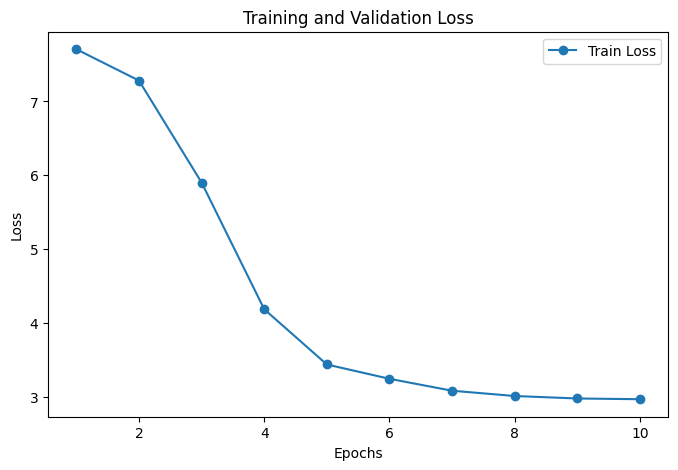

In [35]:
epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Train Loss", marker='o')
# plt.plot(epochs, validation_loss, label="Validation Loss", marker='s')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

### Load Best Checkpoint

In [38]:
model = DeepSpeech2() 
model.load_state_dict(torch.load("best_weights.pt", weights_only=True))

<All keys matched successfully>

### Inference Audio

In [138]:
def inference(path_to_audio, model, tokenizer, sampling_rate = 16000, device="cpu"): 

    # Transforms
    audio2mels = T.MelSpectrogram(
                sample_rate = sampling_rate,
                n_mels=80 
            )

    amp2db = T.AmplitudeToDB(
        top_db=80.0
    ) 

    audio, orig_sr = torchaudio.load(path_to_audio, normalize=True) #normalize: true, convert into [-1, 1], normalize: false, audio bit is between [0, 255]
    if orig_sr != sampling_rate:
        audio = torchaudio.functional.resample(audio, orig_freq=orig_sr, new_freq=self.sampling_rate) # re-sample to 16.000

    # audio: waveform
    mel = audio2mels(audio) # to MelSpectrogram
    # print(audio.shape) => [1, 170400]
    # print(mel.shape) => [1, 80, 853]: 80 bins, 
    # 853 time steps: after sliding window of hann_window (400 windowsize with 200 overlap default value)

    mel = amp2db(mel) # to amplitude to Decibel => see diff frequencies lighting up at the diff time steps
    
    # plt.figure(figsize=(15,5))
    # plt.imshow(mel[0])
    # plt.show()

    mel = (mel - mel.mean())/(mel.std() + 1e-6) # 1e-6 to avoid deviding by zero, to nomalize
    mel = mel.unsqueeze(0) # add in batch dimension 
    
    src_len = torch.tensor([mel.shape[-1]]) # compute src_len

    model = model.to(DEVICE) # set model device 

    with torch.no_grad():
        pred_logits, _ = model(mel.to(DEVICE), src_len)

   
    print(pred_logits.shape)
    pred_logits = pred_logits.squeeze()
    print(pred_logits)
    print(pred_logits[0])
    print(np.argmax(pred_logits[0]))

    # pred_tokens = pred_logits.squeeze().argmax(axis=-1).tolist() 

    # pred_transcript = tokenizer.decode(pred_tokens)

    return "" # pred_transcript

    


In [139]:
path_to_sample, transcript, audio_name = testset.librispeech_data[0]

# print(path_to_sample)
# print(transcript)

pred_transcript = inference(path_to_sample, model, tokenizer)
# audio, sampling_rate = torchaudio.load(path_to_sample)
# Audio(audio, rate=sampling_rate)

torch.Size([1, 601, 32])
tensor([[ 3.4655, -0.8934, -0.1968,  ..., -0.8135, -0.7895, -1.0937],
        [ 3.8081, -1.1144, -0.3130,  ..., -0.8125, -0.8503, -1.0887],
        [ 3.9144, -1.2295, -0.4621,  ..., -0.7045, -0.8431, -1.1028],
        ...,
        [ 4.5212, -1.2536, -1.3415,  ..., -0.9915, -1.3240, -1.7721],
        [ 4.4183, -1.1785, -1.3168,  ..., -0.9530, -1.3697, -1.7227],
        [ 4.1678, -1.0654, -1.1727,  ..., -0.9002, -1.4608, -1.5587]])
tensor([ 3.4655, -0.8934, -0.1968, -0.7706,  1.1330,  0.6450,  0.6645,  0.4799,
         0.6765,  0.2182,  0.2871,  0.3882,  0.2251, -0.0490,  0.2024, -0.0281,
         0.3158, -0.1410,  0.4343, -0.3411, -0.5491, -0.3600, -0.3501, -0.4274,
        -0.2905, -0.5145, -0.5716, -0.6835, -0.5901, -0.8135, -0.7895, -1.0937])
tensor(0)


In [68]:
dt = testset.data[0]

In [92]:
mel = dt['input_values']
print(mel.shape)
mel = mel.T.unsqueeze(0).unsqueeze(0) # add batchsize
print(mel.shape)

torch.Size([1201, 80])
torch.Size([1, 1, 80, 1201])


In [93]:
src_len = torch.tensor([mel.shape[-1]]) # compute src_len
src_len

tensor([1201])

In [116]:
src_len = torch.tensor([mel.shape[-1]]) # compute src_len

model = model.to(DEVICE) # set model device 

with torch.no_grad():
    pred_logits, _ = model(mel.to(DEVICE), src_len)


In [99]:
pred_logits.squeeze().shape

torch.Size([601, 32])

In [104]:
pred_logits.squeeze().argmax(axis=0).tolist()

[585,
 151,
 0,
 293,
 569,
 558,
 371,
 556,
 224,
 149,
 579,
 131,
 444,
 113,
 333,
 275,
 0,
 157,
 0,
 145,
 65,
 295,
 150,
 488,
 151,
 371,
 296,
 151,
 152,
 154,
 293,
 492]

In [113]:
pred_tokens = pred_logits.squeeze()
pred_tokens.shape

torch.Size([601, 32])

In [108]:
### Prediction ###
pred_transcript = tokenizer.decode(pred_tokens)
pred_transcript

'<unk><unk><unk><unk>'

In [107]:
pred_transcript

'<unk><unk><unk><unk>'

In [114]:
pred_transcript = inference(path_to_sample, model, tokenizer)

In [115]:
print(pred_transcript)

In [140]:
len(trainset.librispeech_data)

2864